# Cortex Hierarchy with the SILVA Package

This notebook checks the cortex-style architecture path:

$$
x
\xrightarrow{R_\phi}
u_0
\xrightarrow{\alpha_1}
z_1^\star
\xrightarrow{\tanh}
u_1
\xrightarrow{\alpha_2}
z_2^\star
\xrightarrow{R_\psi}
\hat y.
$$

Each cortex point solves

$$
z_\ell^\star
=
F_{\theta_\ell}(z_\ell^\star,u_{\ell-1}),
$$

with damped solver steps

$$
z_{\ell,k+1}
=
(1-\alpha_\ell)z_{\ell,k}
+\alpha_\ell F_{\theta_\ell}(z_{\ell,k},u_{\ell-1}).
$$

The goal is to verify package behavior: flexible internal modules, different
architectures at different points, different solvers, different alphas,
gradients, and an image-cortex preset.

In [1]:
from pathlib import Path
import importlib.util
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/jseluis/silva-networks.git"

def find_local_silva_root():
    candidates = [
        Path.cwd(),
        Path("/content/silva-networks"),
        Path("/content/drive/MyDrive/silva-networks"),
    ]
    root = Path.cwd()
    while root != root.parent:
        candidates.append(root)
        root = root.parent
    for candidate in candidates:
        if (candidate / "src" / "silva_networks").exists():
            return candidate
    return None

root = find_local_silva_root()
if root is not None:
    sys.path.insert(0, str(root / "src"))
elif IN_COLAB and importlib.util.find_spec("silva_networks") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", f"git+{REPO_URL}"])
    root = Path.cwd()
else:
    root = Path.cwd()

In [2]:
import torch
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})

from silva_networks import (
    SILVACortexLayer,
    SILVACortexNetwork,
    SILVAImageCortexClassifier,
    SolverConfig,
    resolve_device,
)

torch.manual_seed(11)
device = resolve_device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## A Deep Internal Network Inside One Equilibrium Point

The internal transition network $B_\theta$ can contain many trainable layers:

$$
B_\theta(a)
=
B_{\theta,10}\circ\cdots\circ B_{\theta,1}(a).
$$

The cortex point then adds this field to the stimulus and the optional
interaction branches before the solver damping is applied.

In [3]:
def deep_state_network(dim, depth):
    modules = []
    for _ in range(depth):
        modules += [torch.nn.Linear(dim, dim), torch.nn.Tanh()]
    modules.append(torch.nn.Linear(dim, dim))
    return torch.nn.Sequential(*modules)


class StimulusGate(torch.nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.gate = torch.nn.Linear(dim, dim)

    def forward(self, z, stimulus):
        return torch.sigmoid(self.gate(stimulus)) * z

In [4]:
model = SILVACortexNetwork(
    [
        SILVACortexLayer(
            input_dim=5,
            state_dim=14,
            state_network=deep_state_network(14, depth=10),
            self_terms=torch.nn.Linear(14, 14, bias=False),
            interaction_terms=[StimulusGate(14)],
            config=SolverConfig(solver="picard", max_iter=6, alpha=0.5),
        ),
        SILVACortexLayer(
            input_encoder=torch.nn.Linear(14, 10),
            state_dim=10,
            state_network=torch.nn.Sequential(
                torch.nn.Linear(10, 20),
                torch.nn.GELU(),
                torch.nn.Linear(20, 10),
            ),
            config=SolverConfig(solver="anderson", max_iter=6, alpha=0.2, history=3),
            normalize=False,
        ),
    ],
    links="tanh",
    head=torch.nn.Linear(10, 2),
).to(device)

x = torch.randn(8, 5, device=device)
y = torch.tensor([0, 1, 0, 1, 0, 1, 0, 1], device=device)

result = model(x, return_results=True)
loss = torch.nn.functional.cross_entropy(result.output, y)
loss.backward()

print("logits shape:", tuple(result.output.shape))
print("state shapes:", [tuple(state.shape) for state in result.states])
print("solvers:", [r.solver for r in result.solver_results])
print("alphas:", [layer.config.alpha for layer in model.layers])
print("gradient reaches layer 1 encoder:", model.layers[0].input_encoder.weight.grad is not None)

logits shape: (8, 2)
state shapes: [(8, 14), (8, 10)]
solvers: ['picard', 'anderson']
alphas: [0.5, 0.2]
gradient reaches layer 1 encoder: True


## Residual Curves

The two equilibrium points solve different equations. Their residual curves are
not expected to be identical because their transition maps, solvers, and alphas
are different.

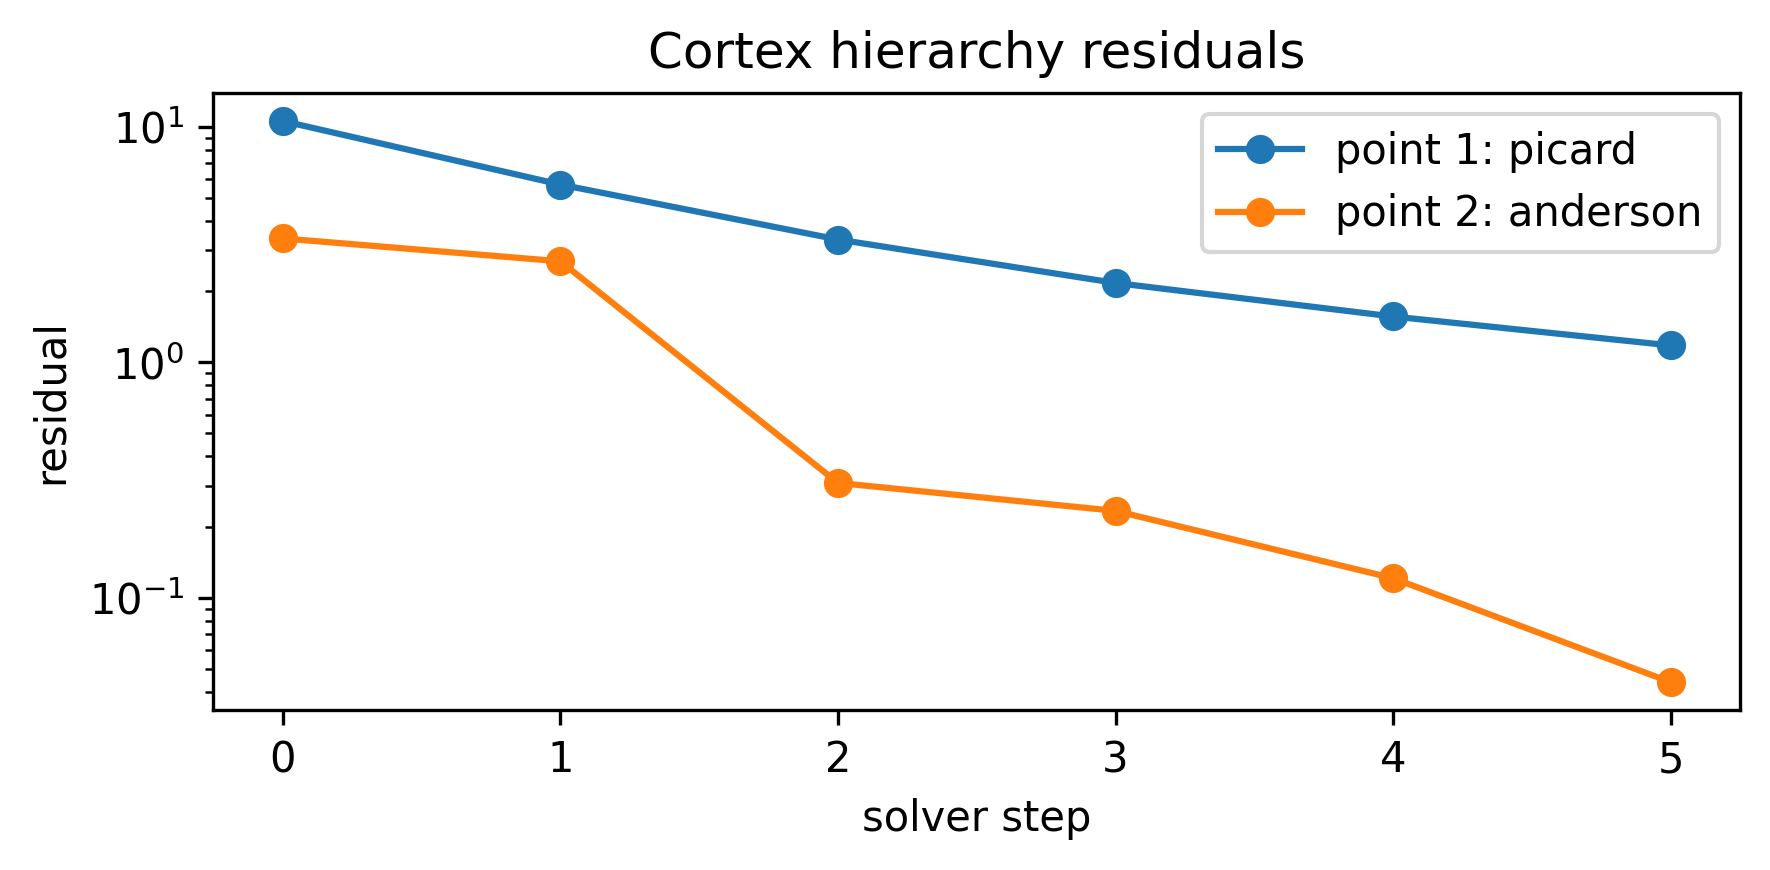

In [5]:
plt.figure(figsize=(6, 3))
for i, solver_result in enumerate(result.solver_results, start=1):
    plt.plot(solver_result.residuals, marker="o", label=f"point {i}: {solver_result.solver}")
plt.yscale("log")
plt.xlabel("solver step")
plt.ylabel("residual")
plt.title("Cortex hierarchy residuals")
plt.legend()
plt.tight_layout()

## Alpha Sweep

For a fixed transition, smaller $\alpha$ mixes less of the new field value at
each iteration:

$$
z_{k+1}-z_k
=
\alpha(F_\theta(z_k,x)-z_k).
$$

The step size is proportional to $\alpha$. This is why a fast first point and
a slower second point can be encoded directly by separate `SolverConfig`
objects.

In [6]:
base_x = torch.randn(4, 3, device=device)
alpha_summaries = []
for alpha in [0.2, 0.5, 0.8]:
    layer = SILVACortexLayer(
        input_dim=3,
        state_dim=6,
        state_network=torch.nn.Linear(6, 6),
        config=SolverConfig(solver="picard", max_iter=5, alpha=alpha),
        normalize=False,
    ).to(device)
    out = layer(base_x, return_result=True)
    alpha_summaries.append((alpha, out.residuals))

for alpha, residuals in alpha_summaries:
    print(alpha, [round(v, 6) for v in residuals])

0.2 [2.099364, 1.732769, 1.432884, 1.185844, 0.981742]
0.5 [2.352644, 1.267768, 0.713337, 0.406747, 0.233999]
0.8 [2.607736, 0.784937, 0.31112, 0.134966, 0.064093]


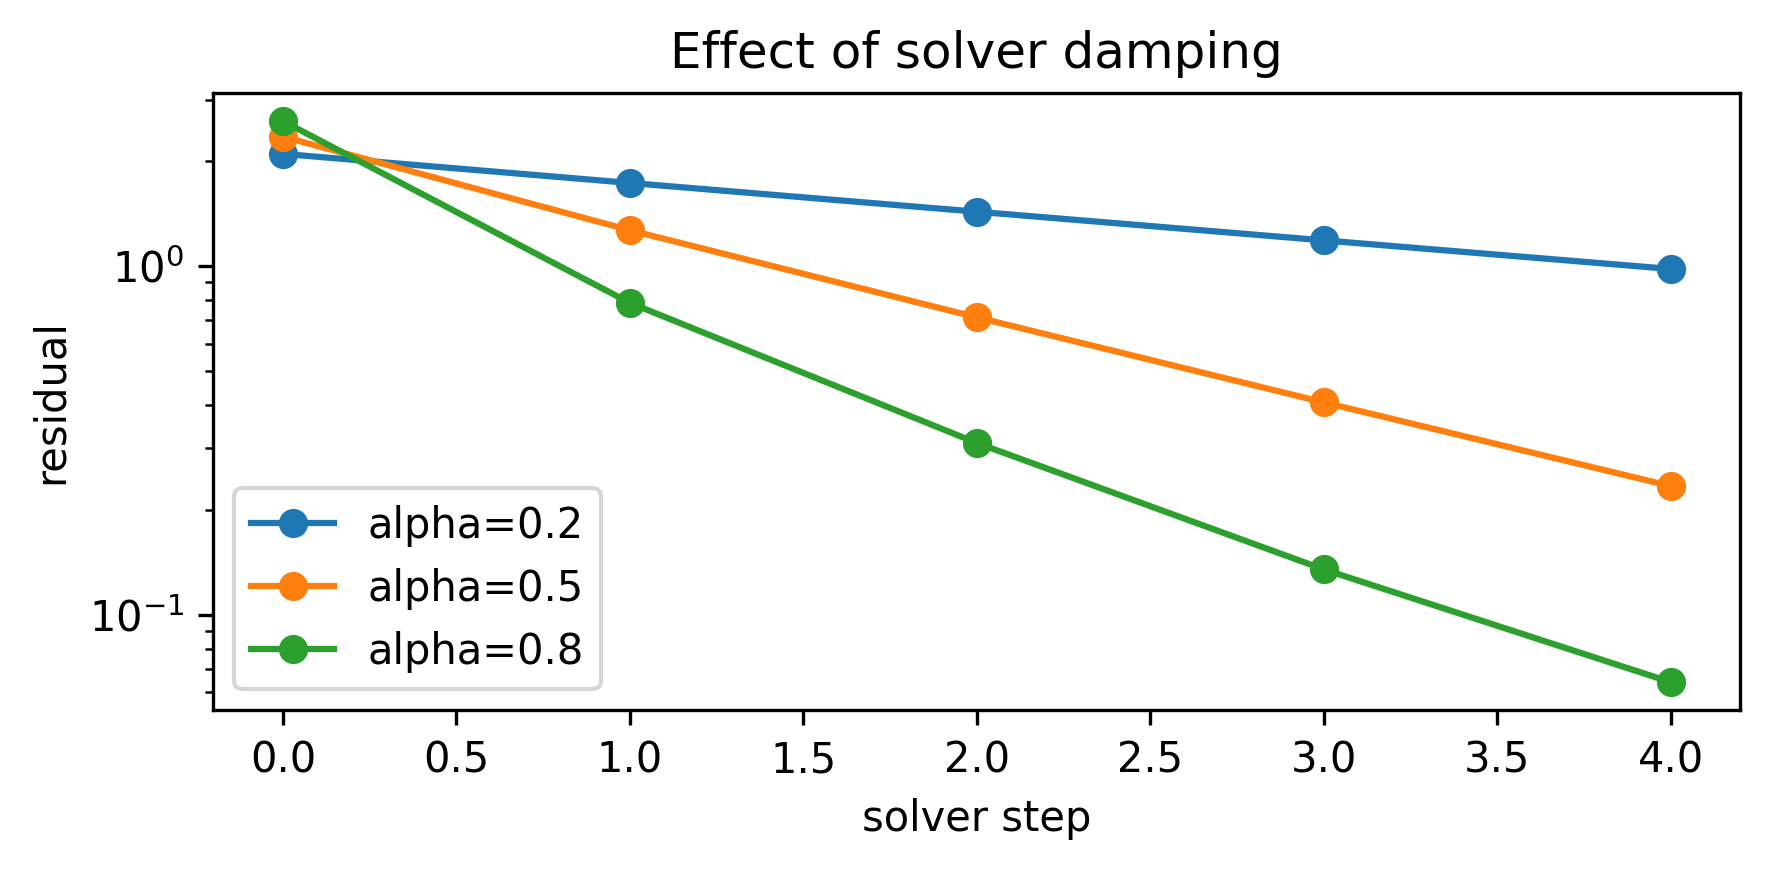

In [7]:
plt.figure(figsize=(6, 3))
for alpha, residuals in alpha_summaries:
    plt.plot(residuals, marker="o", label=f"alpha={alpha}")
plt.yscale("log")
plt.xlabel("solver step")
plt.ylabel("residual")
plt.title("Effect of solver damping")
plt.legend()
plt.tight_layout()

## Image Cortex Preset

`SILVAImageCortexClassifier` packages the convolutional-retina path:

$$
u_0=C_\psi(x),
\qquad
z_1^\star
\xrightarrow{\tanh}
z_2^\star.
$$

The local branch can be the dynamic hidden-channel kNN term, and the global
branch can be per-sample channel attention. Both remain configurable.

In [8]:
image_model = SILVAImageCortexClassifier(
    in_channels=3,
    hidden_dim=[8, 6],
    num_classes=2,
    image_size=8,
    attention_mode="simple",
    graph_mode="GAT",
    k_neighbors=2,
    alphas=(0.5, 0.2),
    max_iter=3,
    internal_depth=2,
    self_interaction=True,
    dropout=0.0,
).to(device)

images = torch.randn(4, 3, 8, 8, device=device)
labels = torch.tensor([0, 1, 0, 1], device=device)
image_result = image_model(images, return_results=True)
image_loss = torch.nn.functional.cross_entropy(image_result.output, labels)
image_loss.backward()

print("image logits:", tuple(image_result.output.shape))
print("image states:", [tuple(state.shape) for state in image_result.states])
print("image solvers:", [r.solver for r in image_result.solver_results])
print("retina gradient:", image_model.retina.conv1.weight.grad is not None)

image logits: (4, 2)
image states: [(4, 8), (4, 6)]
image solvers: ['picard', 'picard']
retina gradient: True


## What This Enables

The same grammar covers the article configurations and extensions:

| Need | Package control |
| --- | --- |
| convolutional front end | `SILVAImageCortexClassifier.retina` or custom `input_encoder` |
| many layers inside one point | `state_network=nn.Sequential(...)` or a module list |
| different point architectures | one `SILVACortexLayer` per point |
| different alphas | one `SolverConfig(alpha=...)` per point |
| different solvers | Picard, Anderson, or Broyden per point |
| local/global/self ablations | pass modules, omit modules, or use zero modules |
| user datasets | adapt to tensors, then call the same PyTorch modules |

## Citation

Dr. Jose Luis Silva. SILVA Networks. Version 1.0.0. MIT License.
https://github.com/jseluis/silva-networks
https://doi.org/10.5281/zenodo.21770099